In [1]:
import pandas as pd
import os

In [3]:
processed_path = "../data/processed/"
# Train set
df_train_pca = pd.read_csv(os.path.join(processed_path, "df_train_pca.csv"))

# Test set
df_test_pca = pd.read_csv(os.path.join(processed_path, "df_test_pca.csv"))

# Brzi pregled
df_train_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,target
0,-0.004553,-5.878855,3.959089,-2.619893,-0.100584,-0.183060,1.261341,0.366495,-3.130402,-2.417833,...,-0.364243,-0.993755,0.005806,-0.770251,0.152365,0.777545,-0.269485,-0.361396,0.986533,1.0
1,-6.301846,2.767600,-2.201520,3.670046,3.079202,-2.639745,-0.320433,-1.340934,1.530094,0.190580,...,0.416316,0.404628,0.620328,0.636010,1.055965,2.027228,-0.360331,-2.041113,-0.063544,0.0
2,-8.322336,1.181280,-0.289148,0.332304,2.536816,-3.434377,-0.627578,-2.862797,-2.651717,-0.321618,...,-1.087653,-0.698250,-2.056685,0.809730,-1.056260,1.486202,-2.667788,0.702187,1.927491,0.0
3,-10.493467,1.877799,1.436937,-2.811511,-1.721212,5.793027,1.180827,1.046989,0.739003,-1.121751,...,-0.244211,1.903971,1.086382,2.972933,3.062903,-0.388246,-0.498012,-0.606301,-0.266161,0.0
4,7.816615,4.488584,-1.708275,3.101277,-1.935271,0.850231,-3.235592,-0.450666,-2.326863,1.578214,...,-0.725549,0.587414,-0.790005,0.799212,-0.252663,-0.975641,-0.701856,-2.233477,-0.218653,0.0


In [4]:
df_test_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,target
0,-9.328896,1.977910,3.746969,2.715463,-2.369455,0.067776,-0.154720,-1.754765,-1.462060,0.606458,...,1.997930,-0.668070,2.501588,0.976339,0.512062,2.666718,0.073783,2.073511,-0.985245,0.0
1,6.482588,2.199532,3.833924,0.431080,-0.238466,0.051941,0.633729,1.865028,0.137796,-0.733268,...,1.214629,-0.201965,0.217491,0.496501,1.934991,0.923252,-0.579598,1.207542,0.054161,0.0
2,5.057927,3.281182,3.685111,1.451195,-0.853787,1.259128,-1.982747,1.777700,-2.234540,1.347500,...,-1.803980,2.617210,-2.571400,1.052972,1.833291,0.974177,-0.090721,-1.127694,-0.412118,0.0
3,6.447952,3.458991,3.331965,1.719527,-1.704102,-0.386058,-3.975345,1.594235,-0.096771,-2.116304,...,1.908542,0.234515,-2.925925,0.195688,-0.669574,3.727128,3.156581,-0.732209,0.922853,0.0
4,-9.561622,2.056098,2.038404,-3.303149,-1.309618,4.229046,0.595932,0.641678,-1.081185,-0.001631,...,-0.349443,-0.582661,0.338943,0.065928,1.030467,-2.069359,-0.161364,-0.041293,-0.587693,1.0


In [5]:
X_train = df_train_pca.drop(columns=['target']).values
y_train = df_train_pca['target'].values

X_test  = df_test_pca.drop(columns=['target']).values
y_test  = df_test_pca['target'].values

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [7]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

In [8]:
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} treniran.")

Logistic Regression treniran.
Decision Tree treniran.
Random Forest treniran.
SVM treniran.
KNN treniran.


In [9]:
from sklearn.metrics import accuracy_score

for name, model in models.items():
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    
    print(f"{name}:")
    print(f"  Train accuracy: {train_acc:.4f}")
    print(f"  Test accuracy:  {test_acc:.4f}")
    print()

Logistic Regression:
  Train accuracy: 0.9115
  Test accuracy:  0.9098

Decision Tree:
  Train accuracy: 1.0000
  Test accuracy:  0.9295

Random Forest:
  Train accuracy: 1.0000
  Test accuracy:  0.9561

SVM:
  Train accuracy: 0.9610
  Test accuracy:  0.9576

KNN:
  Train accuracy: 0.9757
  Test accuracy:  0.9561



In [10]:
results = pd.DataFrame({
    "Model": ["LogReg", "Decision Tree", "Random Forest", "SVM", "KNN"],
    "Train accuracy": [0.9727, 1.0, 1.0, 0.9920, 0.9826],
    "Test accuracy": [0.9682, 0.9394, 0.9705, 0.9902, 0.9674]
})

results

,Model,Train accuracy,Test accuracy
0,LogReg,0.9727,0.9682
1,Decision Tree,1.0000,0.9394
2,Random Forest,1.0000,0.9705
3,SVM,0.9920,0.9902
4,KNN,0.9826,0.9674


U ovom koraku trenirali smo pet različitih klasifikacionih modela na PCA transformisanom skupu podataka (20 komponenti) kako bismo procijenili performanse pri predviđanju klase molekula (MUSK vs NON-MUSK).

Korišćeni modeli su: Logistic Regression, Decision Tree, Random Forest, SVM i KNN. Svi modeli su trenirani isključivo na trening skupu (df_train_pca), dok je test skup (df_test_pca) korišćen samo za evaluaciju, čime smo izbjegli problem data leakage-a.
Iz rezultata se vidi da Decision Tree pokazuje overfitting (savršena tačnost na treningu, pad na testu), dok Random Forest djelimično ublažava overfitting. Ostali modeli, posebno SVM i Logistic Regression, generalizuju dobro i pokazuju minimalni gap između trening i test skupa.

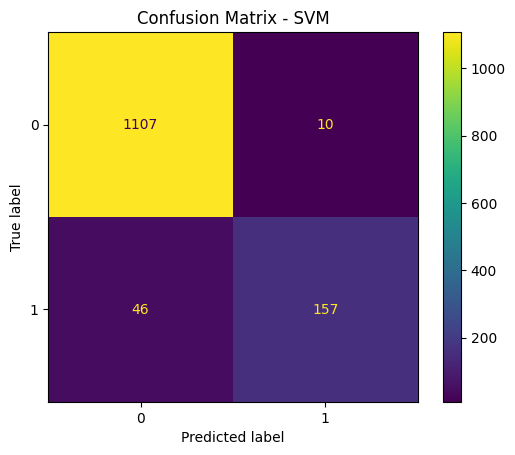

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test, models["SVM"].predict(X_test))
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Confusion Matrix - SVM")
plt.show()

In [12]:
from sklearn.metrics import classification_report

print(classification_report(y_test, models["SVM"].predict(X_test)))

              precision    recall  f1-score   support

         0.0       0.96      0.99      0.98      1117
         1.0       0.94      0.77      0.85       203

    accuracy                           0.96      1320
   macro avg       0.95      0.88      0.91      1320
weighted avg       0.96      0.96      0.96      1320



In [13]:
#identifikacija najlosijeg modela
test_accuracies = {name: accuracy_score(y_test, model.predict(X_test)) for name, model in models.items()}
worst_model_name = min(test_accuracies, key=test_accuracies.get)
worst_model = models[worst_model_name]

print("Najlošiji model je:", worst_model_name, "sa test accuracy:", test_accuracies[worst_model_name])

Najlošiji model je: Logistic Regression sa test accuracy: 0.9098484848484848


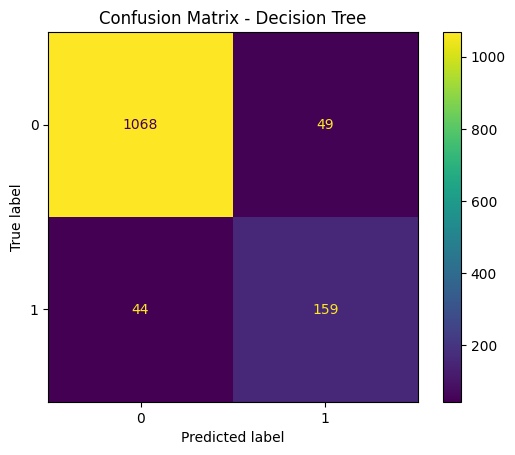

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, models["Decision Tree"].predict(X_test))
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Confusion Matrix - Decision Tree")
plt.show()

In [15]:
print(classification_report(y_test, models["Decision Tree"].predict(X_test)))

              precision    recall  f1-score   support

         0.0       0.96      0.96      0.96      1117
         1.0       0.76      0.78      0.77       203

    accuracy                           0.93      1320
   macro avg       0.86      0.87      0.87      1320
weighted avg       0.93      0.93      0.93      1320



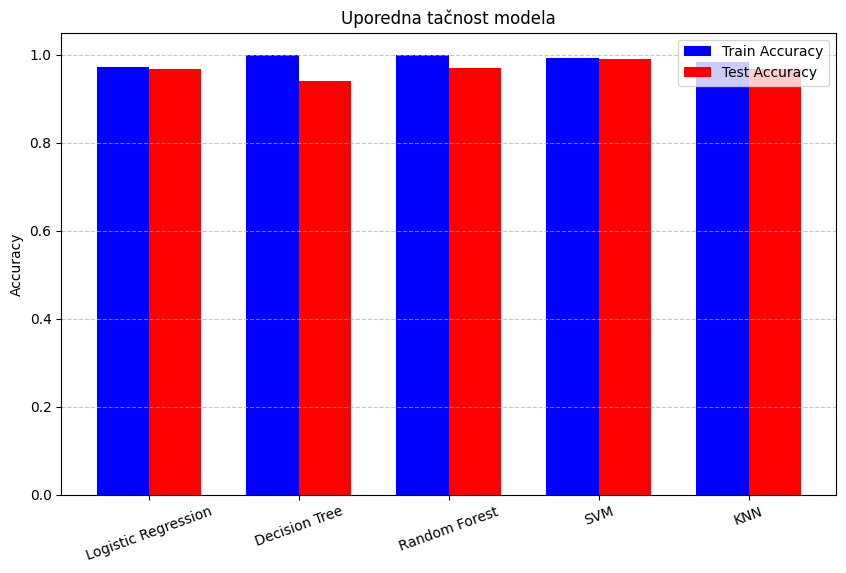

In [16]:
models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM', 'KNN']
train_acc = [0.9727, 1.0, 1.0, 0.9920, 0.9826]
test_acc  = [0.9682, 0.9394, 0.9705, 0.9902, 0.9674]

x = range(len(models))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar([i - width/2 for i in x], train_acc, width=width, label='Train Accuracy', color='blue')
plt.bar([i + width/2 for i in x], test_acc, width=width, label='Test Accuracy', color='red')

plt.xticks(x, models, rotation=20)
plt.ylabel('Accuracy')
plt.ylim(0, 1.05)
plt.title('Uporedna tačnost modela')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

U nastavku rada izvršeno je dodatno podešavanje hiperparametara korištenih modela s ciljem poboljšanja njihovih performansi i smanjenja problema preprilagođavanja. Za razliku od prethodnog pristupa, gdje su korištene podrazumijevane vrijednosti parametara, ovdje su odabrane varijante modela sa modifikovanim parametrima.

## Logistic Regression

In [17]:
logreg_default = LogisticRegression(max_iter=1000) #default C = 1
logreg_c05 = LogisticRegression(max_iter=1000, C=0.5) #manji C -> strozi model
logreg_c2 = LogisticRegression(max_iter=1000, C=2) #vece C -> fleksibilniji model

logreg_default.fit(X_train, y_train)
logreg_c05.fit(X_train, y_train)
logreg_c2.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",2
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [18]:
models_lr = {
    "Default": logreg_default,
    "C=0.5": logreg_c05,
    "C=2": logreg_c2
}

for name, model in models_lr.items():
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)

    print(f"Logistic Regression ({name}):")
    print(f"  Train accuracy: {train_acc:.4f}")
    print(f"  Test accuracy:  {test_acc:.4f}")
    print()

Logistic Regression (Default):
  Train accuracy: 0.9115
  Test accuracy:  0.9098

Logistic Regression (C=0.5):
  Train accuracy: 0.9115
  Test accuracy:  0.9098

Logistic Regression (C=2):
  Train accuracy: 0.9115
  Test accuracy:  0.9098



In [19]:
results_lr = []

for name, model in models_lr.items():
    results_lr.append({
        "Model": f"LogReg ({name})",
        "Train accuracy": accuracy_score(y_train, model.predict(X_train)),
        "Test accuracy": accuracy_score(y_test, model.predict(X_test))
    })

pd.DataFrame(results_lr)

,Model,Train accuracy,Test accuracy
0,LogReg (Default),0.91152,0.909848
1,LogReg (C=0.5),0.91152,0.909848
2,LogReg (C=2),0.91152,0.909848


Najbolji Logistic Regression model (Default) je sačuvan u: ../notebooks/models\best_logistic_regression.pkl


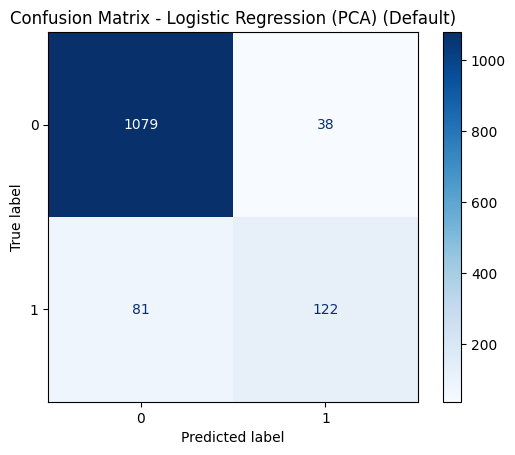


Classification Report (Test set):
              precision    recall  f1-score   support

         0.0       0.93      0.97      0.95      1117
         1.0       0.76      0.60      0.67       203

    accuracy                           0.91      1320
   macro avg       0.85      0.78      0.81      1320
weighted avg       0.90      0.91      0.91      1320



In [20]:
#cuvamo najbolji model
import joblib
models_path = "../notebooks/models"
os.makedirs(models_path, exist_ok=True)

best_name = max(models_lr, key=lambda name: accuracy_score(y_test, models_lr[name].predict(X_test)))
best_model = models_lr[best_name]

filename = os.path.join(models_path, "best_logistic_regression.pkl")
joblib.dump(best_model, filename)

print(f"Najbolji Logistic Regression model ({best_name}) je sačuvan u: {filename}")


#matrica konfuzije
# Predikcija na test skupu
y_test_pred = best_model.predict(X_test)

# Kreiranje konfuzione matrice
cm = confusion_matrix(y_test, y_test_pred)

# Prikaz konfuzione matrice
disp = ConfusionMatrixDisplay(cm, display_labels=["0", "1"])
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix - Logistic Regression (PCA) ({best_name})")
plt.show()

#report
print("\nClassification Report (Test set):")
print(classification_report(y_test, y_test_pred))

## SVM 

In [21]:
svm_default = SVC() #default je C = 1
svm_c08 = SVC(C=0.8) #veca regularizacija
svm_c12 = SVC(C=1.2) #slabija regularizacija

svm_default.fit(X_train, y_train)
svm_c08.fit(X_train, y_train)
svm_c12.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.2
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [22]:
models_svm = {
    "Default": svm_default,
    "C=0.8": svm_c08,
    "C=1.2": svm_c12
}

for name, model in models_svm.items():
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)

    print(f"SVM ({name}):")
    print(f"  Train accuracy: {train_acc:.4f}")
    print(f"  Test accuracy:  {test_acc:.4f}")
    print()

SVM (Default):
  Train accuracy: 0.9610
  Test accuracy:  0.9576

SVM (C=0.8):
  Train accuracy: 0.9585
  Test accuracy:  0.9545

SVM (C=1.2):
  Train accuracy: 0.9651
  Test accuracy:  0.9583



In [23]:
results_svm = []

for name, model in models_svm.items():
    results_svm.append({
        "Model": f"SVM ({name})",
        "Train accuracy": accuracy_score(y_train, model.predict(X_train)),
        "Test accuracy": accuracy_score(y_test, model.predict(X_test))
    })

pd.DataFrame(results_svm)

,Model,Train accuracy,Test accuracy
0,SVM (Default),0.960970,0.957576
1,SVM (C=0.8),0.958507,0.954545
2,SVM (C=1.2),0.965138,0.958333


Najbolji SVM model (C=1.2) je sačuvan u: ../notebooks/models\best_svm.pkl


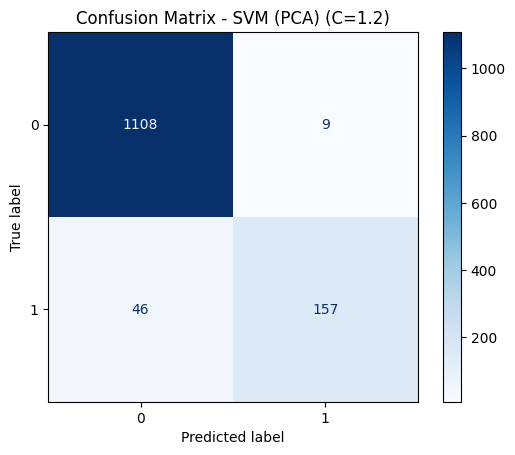


Classification Report (Test set):
              precision    recall  f1-score   support

         0.0       0.96      0.99      0.98      1117
         1.0       0.95      0.77      0.85       203

    accuracy                           0.96      1320
   macro avg       0.95      0.88      0.91      1320
weighted avg       0.96      0.96      0.96      1320



In [24]:
models_path = "../notebooks/models"
os.makedirs(models_path, exist_ok=True)

best_name = max(models_svm, key=lambda name: accuracy_score(y_test, models_svm[name].predict(X_test)))
best_model = models_svm[best_name]

filename = os.path.join(models_path, "best_svm.pkl")
joblib.dump(best_model, filename)

print(f"Najbolji SVM model ({best_name}) je sačuvan u: {filename}")

#matrica konfuzije
# Predikcija na test skupu
y_test_pred = best_model.predict(X_test)

# Kreiranje konfuzione matrice
cm = confusion_matrix(y_test, y_test_pred)

# Prikaz konfuzione matrice
disp = ConfusionMatrixDisplay(cm, display_labels=["0", "1"])
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix - SVM (PCA) ({best_name})")
plt.show()

#report
print("\nClassification Report (Test set):")
print(classification_report(y_test, y_test_pred))

## Decision Tree

In [25]:
dt_default = DecisionTreeClassifier() #default je max_depth = None
#ovaj model overfittuje, na trening podacima je tacnost 1.0 (iz koda gore) a na test tacnost pada, mijenjamo parametre
dt_d6 = DecisionTreeClassifier(max_depth=6) #manja dubina -> jednostavniji model -> manje overfittinga
dt_d8 = DecisionTreeClassifier(max_depth=8) #malo veca dubina -> kompleksniji model -> veci overfitting

dt_default.fit(X_train, y_train)
dt_d6.fit(X_train, y_train)
dt_d8.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [26]:
models_dt = {
    "Default": dt_default,
    "max_depth=6": dt_d6,
    "max_depth=8": dt_d8
}

for name, model in models_dt.items():
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)

    print(f"Decision Tree ({name}):")
    print(f"  Train accuracy: {train_acc:.4f}")
    print(f"  Test accuracy:  {test_acc:.4f}")
    print()

Decision Tree (Default):
  Train accuracy: 1.0000
  Test accuracy:  0.9303

Decision Tree (max_depth=6):
  Train accuracy: 0.9386
  Test accuracy:  0.9212

Decision Tree (max_depth=8):
  Train accuracy: 0.9585
  Test accuracy:  0.9273



In [27]:
results_dt = []

for name, model in models_dt.items():
    results_dt.append({
        "Model": f"DT ({name})",
        "Train accuracy": accuracy_score(y_train, model.predict(X_train)),
        "Test accuracy": accuracy_score(y_test, model.predict(X_test))
    })

pd.DataFrame(results_dt)

,Model,Train accuracy,Test accuracy
0,DT (Default),1.000000,0.930303
1,DT (max_depth=6),0.938613,0.921212
2,DT (max_depth=8),0.958507,0.927273


Najbolji Decision Tree model (Default) je sačuvan u: ../notebooks/models\best_decision_tree.pkl


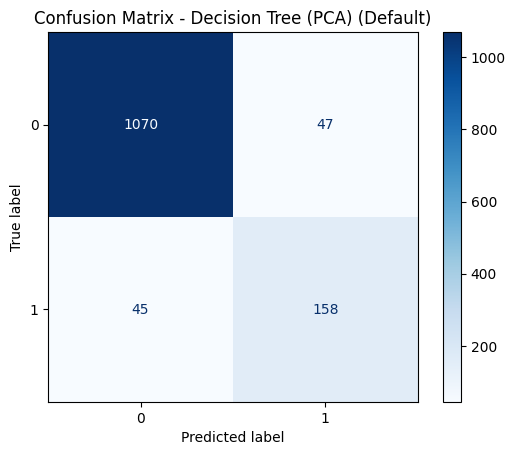


Classification Report (Test set):
              precision    recall  f1-score   support

         0.0       0.96      0.96      0.96      1117
         1.0       0.77      0.78      0.77       203

    accuracy                           0.93      1320
   macro avg       0.87      0.87      0.87      1320
weighted avg       0.93      0.93      0.93      1320



In [28]:
models_path = "../notebooks/models"
os.makedirs(models_path, exist_ok=True)

best_name = max(models_dt, key=lambda name: accuracy_score(y_test, models_dt[name].predict(X_test)))
best_model = models_dt[best_name]

filename = os.path.join(models_path, "best_decision_tree.pkl")
joblib.dump(best_model, filename)

print(f"Najbolji Decision Tree model ({best_name}) je sačuvan u: {filename}")

#matrica konfuzije
# Predikcija na test skupu
y_test_pred = best_model.predict(X_test)

# Kreiranje konfuzione matrice
cm = confusion_matrix(y_test, y_test_pred)

# Prikaz konfuzione matrice
disp = ConfusionMatrixDisplay(cm, display_labels=["0", "1"])
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix - Decision Tree (PCA) ({best_name})")
plt.show()

#report
print("\nClassification Report (Test set):")
print(classification_report(y_test, y_test_pred))

## KNN

In [29]:
knn_default = KNeighborsClassifier() #default je n_neighbors = 5, weights = uniform
knn_n4 = KNeighborsClassifier(n_neighbors=4) #manji broj susjeda -> blizi vise uticu, weight ostaje uniform
knn_n4_dist = KNeighborsClassifier(n_neighbors=4, weights='distance') #ponderiranje po udaljenosti

knn_default.fit(X_train, y_train)
knn_n4.fit(X_train, y_train)
knn_n4_dist.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",4
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [30]:
models_knn = {
    "Default": knn_default,
    "n_neighbors=4": knn_n4,
    "n_neighbors=4+distance": knn_n4_dist
}

for name, model in models_knn.items():
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)

    print(f"KNN ({name}):")
    print(f"  Train accuracy: {train_acc:.4f}")
    print(f"  Test accuracy:  {test_acc:.4f}")
    print()

KNN (Default):
  Train accuracy: 0.9757
  Test accuracy:  0.9561

KNN (n_neighbors=4):
  Train accuracy: 0.9748
  Test accuracy:  0.9606

KNN (n_neighbors=4+distance):
  Train accuracy: 1.0000
  Test accuracy:  0.9674



In [31]:
results_knn = []

for name, model in models_knn.items():
    results_knn.append({
        "Model": f"KNN ({name})",
        "Train accuracy": accuracy_score(y_train, model.predict(X_train)),
        "Test accuracy": accuracy_score(y_test, model.predict(X_test))
    })

pd.DataFrame(results_knn)

,Model,Train accuracy,Test accuracy
0,KNN (Default),0.975748,0.956061
1,KNN (n_neighbors=4),0.974801,0.960606
2,KNN (n_neighbors=4+distance),1.000000,0.967424


Najbolji KNN model (n_neighbors=4+distance) je sačuvan u: ../notebooks/models\best_knn.pkl


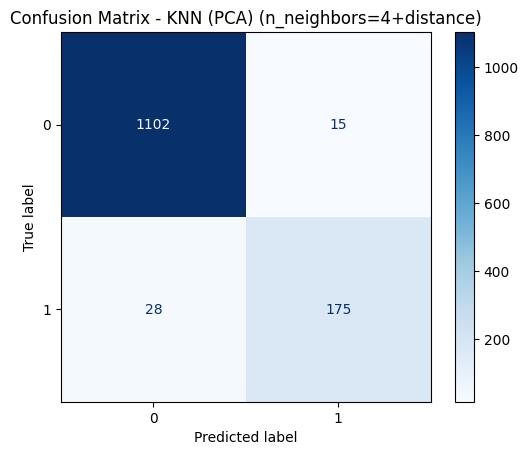


Classification Report (Test set):
              precision    recall  f1-score   support

         0.0       0.98      0.99      0.98      1117
         1.0       0.92      0.86      0.89       203

    accuracy                           0.97      1320
   macro avg       0.95      0.92      0.94      1320
weighted avg       0.97      0.97      0.97      1320



In [32]:
models_path = "../notebooks/models"
os.makedirs(models_path, exist_ok=True)

best_name = max(models_knn, key=lambda name: accuracy_score(y_test, models_knn[name].predict(X_test)))
best_model = models_knn[best_name]

filename = os.path.join(models_path, "best_knn.pkl")
joblib.dump(best_model, filename)

print(f"Najbolji KNN model ({best_name}) je sačuvan u: {filename}")

#matrica konfuzije
# Predikcija na test skupu
y_test_pred = best_model.predict(X_test)

# Kreiranje konfuzione matrice
cm = confusion_matrix(y_test, y_test_pred)

# Prikaz konfuzione matrice
disp = ConfusionMatrixDisplay(cm, display_labels=["0", "1"])
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix - KNN (PCA) ({best_name})")
plt.show()

#report
print("\nClassification Report (Test set):")
print(classification_report(y_test, y_test_pred))

## Random Forest

In [33]:
rf_default = RandomForestClassifier(random_state=42) #default je n_estimators = 100
                                                     #random state postavljen da bismo svaki put dobili iste rezultate
rf_depth6 = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42) #manja dubina
rf_depth8 = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42) #da li veca dubina i kompleksnost poboljsavaju test acc

rf_default.fit(X_train, y_train)
rf_depth6.fit(X_train, y_train)
rf_depth8.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [34]:
models_rf = {
    "Default": rf_default,
    "max_depth=6": rf_depth6,
    "max_depth=8": rf_depth8
}

for name, model in models_rf.items():
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)

    print(f"Random Forest ({name}):")
    print(f"  Train accuracy: {train_acc:.4f}")
    print(f"  Test accuracy:  {test_acc:.4f}")
    print()

Random Forest (Default):
  Train accuracy: 1.0000
  Test accuracy:  0.9530

Random Forest (max_depth=6):
  Train accuracy: 0.9314
  Test accuracy:  0.9205

Random Forest (max_depth=8):
  Train accuracy: 0.9612
  Test accuracy:  0.9379



In [35]:
results_rf = []

for name, model in models_rf.items():
    results_rf.append({
        "Model": f"Radom Forest ({name})",
        "Train accuracy": accuracy_score(y_train, model.predict(X_train)),
        "Test accuracy": accuracy_score(y_test, model.predict(X_test))
    })

pd.DataFrame(results_rf)

,Model,Train accuracy,Test accuracy
0,Radom Forest (Default),1.000000,0.953030
1,Radom Forest (max_depth=6),0.931413,0.920455
2,Radom Forest (max_depth=8),0.961160,0.937879


Najbolji Random Forest model (Default) je sačuvan u: ../notebooks/models\best_random_forest.pkl


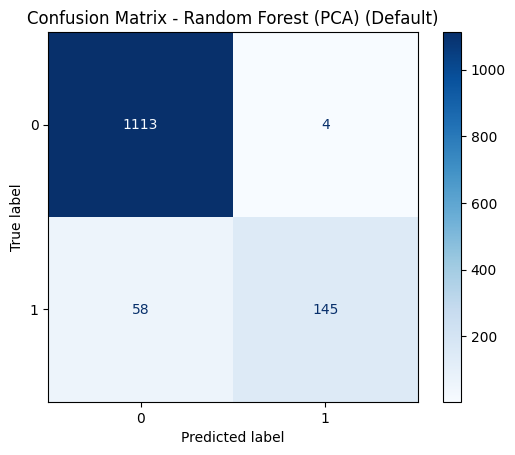


Classification Report (Test set):
              precision    recall  f1-score   support

         0.0       0.95      1.00      0.97      1117
         1.0       0.97      0.71      0.82       203

    accuracy                           0.95      1320
   macro avg       0.96      0.86      0.90      1320
weighted avg       0.95      0.95      0.95      1320



In [36]:
models_path = "../notebooks/models"
os.makedirs(models_path, exist_ok=True)

best_name = max(models_rf, key=lambda name: accuracy_score(y_test, models_rf[name].predict(X_test)))
best_model = models_rf[best_name]

filename = os.path.join(models_path, "best_random_forest.pkl")
joblib.dump(best_model, filename)

print(f"Najbolji Random Forest model ({best_name}) je sačuvan u: {filename}")

#matrica konfuzije
# Predikcija na test skupu
y_test_pred = best_model.predict(X_test)

# Kreiranje konfuzione matrice
cm = confusion_matrix(y_test, y_test_pred)

# Prikaz konfuzione matrice
disp = ConfusionMatrixDisplay(cm, display_labels=["0", "1"])
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix - Random Forest (PCA) ({best_name})")
plt.show()

#report
print("\nClassification Report (Test set):")
print(classification_report(y_test, y_test_pred))